In [11]:
import pandas as pd
ex = pd.read_excel(r"C:\Users\85251\Downloads\ecommerce_sales_analysis .xlsx")
print(ex)

      product_id  product_name        category   price    review_score  \
0            1.0     Product_1        Clothing  190.40             1.7   
1            2.0     Product_2  Home & Kitchen  475.60             3.2   
2            3.0     Product_3            Toys  367.34             4.5   
3            4.0     Product_4            Toys  301.34             3.9   
4            5.0     Product_5           Books   82.23             4.2   
...          ...           ...             ...     ...             ...   
999       1000.0  Product_1000            Toys  225.77             2.1   
1000         NaN           NaN             NaN     NaN             NaN   
1001         NaN           NaN           Note:     NaN    Color Scale:   
1002         NaN           NaN             NaN     NaN     Red: Lowest   
1003         NaN           NaN             NaN     NaN  Green: Largest   

            review_count  sales_month_1  sales_month_2  sales_month_3  \
0                    220          479.

In [12]:
df = ex[:1000]
df.dtypes #spot wrong data type

product_id          float64
product_name         object
category             object
price               float64
review_score         object
review_count         object
sales_month_1       float64
sales_month_2       float64
sales_month_3       float64
sales_month_4       float64
sales_month_5       float64
sales_month_6       float64
sales_month_7       float64
sales_month_8       float64
sales_month_9       float64
sales_month_10      float64
sales_month_11      float64
sales_month_12      float64
total_sales          object
revenue_month_1     float64
revenue_month_2     float64
revenue_month_3     float64
revenue_month_4     float64
revenue_month_5     float64
revenue_month_6     float64
revenue_month_7     float64
revenue_month_8     float64
revenue_month_9     float64
revenue_month_10    float64
revenue_month_11    float64
revenue_month_12    float64
total_revenue        object
dtype: object

In [13]:
df[['review_score', 'review_count', 'total_sales', 'total_revenue']] #inspect

,review_score,review_count,total_sales,total_revenue
0,1.7,220,6421,1222558.4
1,3.2,903,6027,2866441.2
2,4.5,163,5580,2049757.2
3,3.9,951,5022,1513329.48
4,4.2,220,6094,501109.62
...,...,...,...,...
995,3.6,494,5515,277569.95
996,4.8,701,4511,2070864.77
997,1.3,287,5527,401978.71
998,1.2,720,4546,2161032.02


In [14]:
df[['review_score', 'total_revenue']] = df[['review_score', 'total_revenue']].astype('float64')
df[['review_count', 'total_sales']] = df[['review_count', 'total_sales']].astype('int64')
desc = df[['price','review_score','review_count','total_sales','total_revenue']].describe()
desc = desc.apply(lambda col: col.map('{:,.2f}'.format))
desc.to_csv(r"C:\Users\85251\Documents\temp.csv")


C:\Users\85251\AppData\Local\Temp\ipykernel_5272\2558349848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['review_score', 'total_revenue']] = df[['review_score', 'total_revenue']].astype('float64')
C:\Users\85251\AppData\Local\Temp\ipykernel_5272\2558349848.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['review_count', 'total_sales']] = df[['review_count', 'total_sales']].astype('int64')


[0.00011349]
2.9678467549652354
R² Score: 0.0007
p-value for review_count: 0.3876


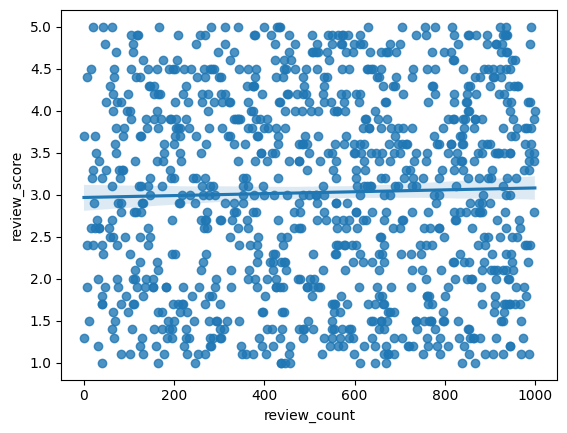

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import f_regression

sns.regplot(data = df, x = "review_count", y = "review_score")
linear_review_count_score = LinearRegression()
linear_review_count_score.fit(df[['review_count']], df.review_score)
print(linear_review_count_score.coef_)
print(linear_review_count_score.intercept_)
y_pred = linear_review_count_score.predict(df[['review_count']])
r2 = r2_score(df['review_score'], y_pred)
print(f"R² Score: {r2:.4f}")
f_stats, p_values = f_regression(df[['review_count']], df['review_score'])
print(f"p-value for review_count: {p_values[0]:.4f}")

We can see a slight positive relationship between review count and score, but insignificant due to the large p-value.

[0.00023456]
2.9695053730680563
R² Score: 0.0008
p-value for price: 0.3603


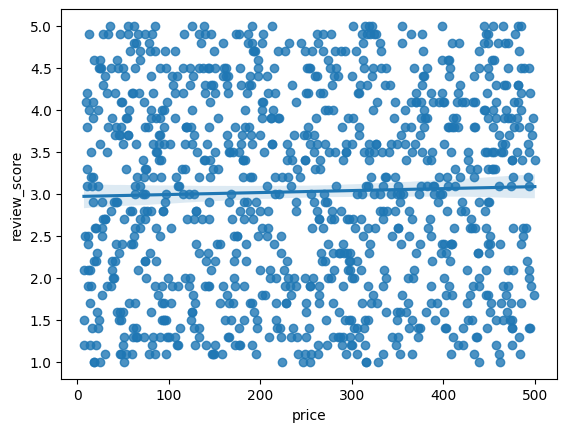

In [16]:
sns.regplot(data = df, x = "price", y = "review_score")
linear_price_score = LinearRegression()
linear_price_score.fit(df[['price']], df.review_score)
print(linear_price_score.coef_)
print(linear_price_score.intercept_)
y_pred = linear_price_score.predict(df[['price']])
r2 = r2_score(df['review_score'], y_pred)
print(f"R² Score: {r2:.4f}")
f_stats, p_values = f_regression(df[['price']], df['review_score'])
print(f"p-value for price: {p_values[0]:.4f}")

From the above graph, we can see a slight positive relationship between price and review_score. But the degree of relationship is quite small, s the R-squared is only 0.0008, means that only 0.08% of the variation of review score is explained by price. Moreover, the p-value for the slope is 0.3603, means that we can't establish their relationship statistically.

[-15.40731321]
6066.559181477598
R² Score: 0.0003
p-value for review_score: 0.5657


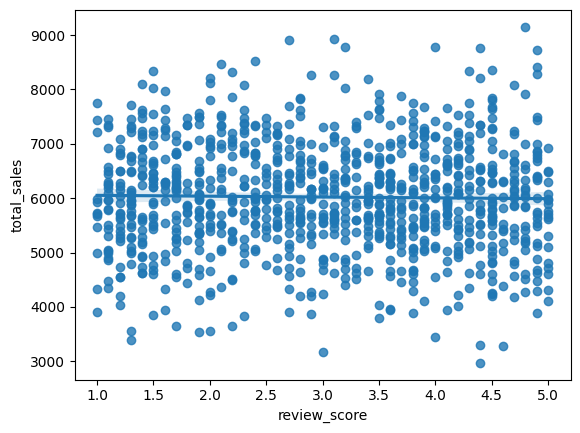

In [17]:
sns.regplot(data = df, x = "review_score", y = "total_sales")
linear_review_score_sales = LinearRegression()
linear_review_score_sales.fit(df[['review_score']], df.total_sales)
print(linear_review_score_sales.coef_)
print(linear_review_score_sales.intercept_)
y_pred = linear_review_score_sales.predict(df[['review_score']])
r2 = r2_score(df['total_sales'], y_pred)
print(f"R² Score: {r2:.4f}")
f_stats, p_values = f_regression(df[['review_score']], df['total_sales'])
print(f"p-value for review_score: {p_values[0]:.4f}")

An insignificant negative relationship is observed between review score and total sales.

[21964.32550412]
1422204.9911237378
R² Score: 0.0008
p-value for review_score: 0.3776


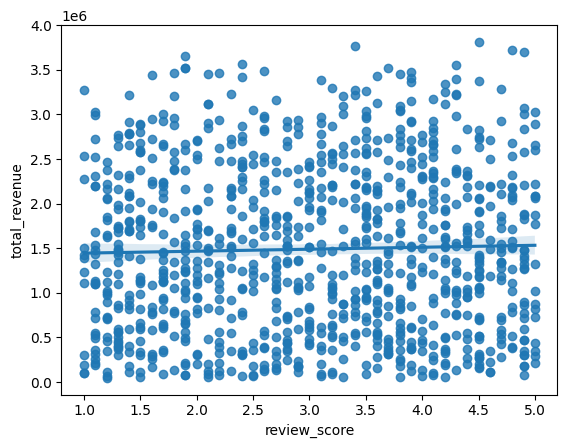

In [18]:
sns.regplot(data = df, x = "review_score", y = "total_revenue")
linear_review_score_revenue = LinearRegression()
linear_review_score_revenue.fit(df[['review_score']], df.total_revenue)
print(linear_review_score_revenue.coef_)
print(linear_review_score_revenue.intercept_)
y_pred = linear_review_score_revenue.predict(df[['review_score']])
r2 = r2_score(df['total_revenue'], y_pred)
print(f"R² Score: {r2:.4f}")
f_stats, p_values = f_regression(df[['review_score']], df['total_revenue'])
print(f"p-value for review_score: {p_values[0]:.4f}")

An insignificant positive relationship is observed between review score and total revenue.

[878970.80964274 250548.02478246]
1488704.1830199999
R² Score: 0.9765
p-value for price: 0.0000
p-value for sales: 0.0000


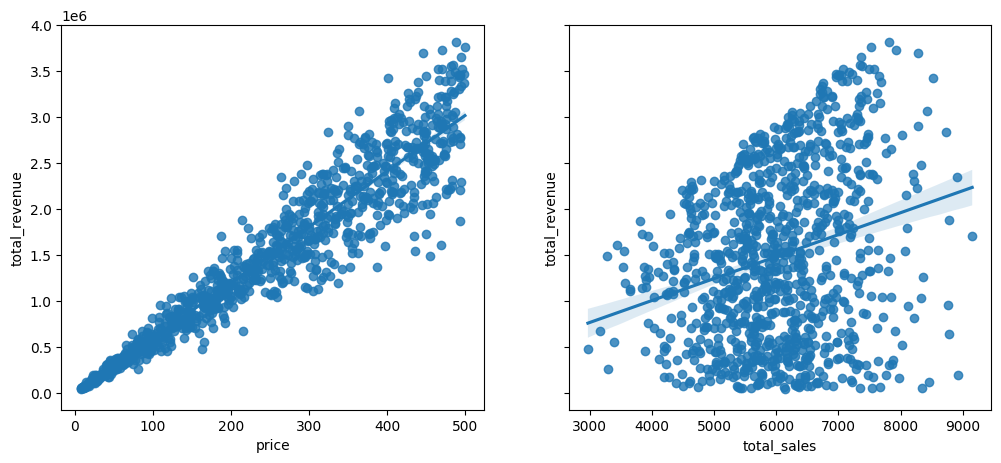

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.regplot(data = df, x = "price", y = "total_revenue", ax=ax1)
sns.regplot(data = df, x = "total_sales", y = "total_revenue", ax=ax2)

X = df[['price', 'total_sales']]
X_mean = X.mean()
X_std = X.std()
X_norm = (X - X_mean)/X_std
linear_price_sales_revenue = LinearRegression()
linear_price_sales_revenue.fit(X_norm, df.total_revenue)
print(linear_price_sales_revenue.coef_)
print(linear_price_sales_revenue.intercept_)
y_pred = linear_price_sales_revenue.predict(X_norm)
r2 = r2_score(df['total_revenue'], y_pred)
print(f"R² Score: {r2:.4f}")
f_stats, p_values = f_regression(X_norm, df['total_revenue'])
print(f"p-value for price: {p_values[0]:.4f}")
print(f"p-value for sales: {p_values[1]:.4f}")

Since total revenue = price * total sales, a higher price or total sales must lead to a higher total revenue. But we can build up a multiple linear regression to discover the significance of each variable. After normalizing price and sales, we can see that the regression coefficient price is 3.5 times of that of sales. This explained the significance of selling goods at high price would generate higher revenue.

[-0.10963537]
6047.066173897772
R² Score: 0.0003
p-value for price: 0.6138


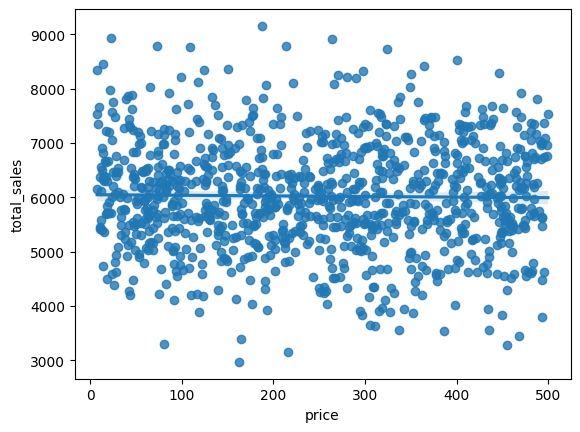

In [20]:
sns.regplot(data = df, x = "price", y = "total_sales")
linear_price_sales = LinearRegression()
linear_price_sales.fit(df[['price']], df.total_sales)
print(linear_price_sales.coef_)
print(linear_price_sales.intercept_)
y_pred = linear_price_sales.predict(df[['price']])
r2 = r2_score(df['total_sales'], y_pred)
print(f"R² Score: {r2:.4f}")
f_stats, p_values = f_regression(df[['price']], df['total_sales'])
print(f"p-value for price: {p_values[0]:.4f}")

Insignificant negative relationship between price and sales.

In [46]:
cate = df['category'].unique().tolist()
print(cate)

['Clothing', 'Home & Kitchen', 'Toys', 'Books', 'Electronics', 'Health', 'Sports']


In [47]:
df_cate = {}
df_cate = {cat: df[df['category'] == cat] for cat in cate}
print(df_cate['Sports'].head(5))  

    product_id product_name category   price  review_score  review_count  \
23        24.0   Product_24   Sports  186.35           4.9           850   
37        38.0   Product_38   Sports   53.35           3.9           672   
43        44.0   Product_44   Sports  455.11           3.5           944   
46        47.0   Product_47   Sports  159.30           1.9           426   
52        53.0   Product_53   Sports  470.05           4.8           313   

    sales_month_1  sales_month_2  sales_month_3  sales_month_4  ...  \
23          162.0          830.0          894.0          970.0  ...   
37          548.0          411.0          485.0          530.0  ...   
43          647.0          467.0          354.0          330.0  ...   
46          127.0          730.0          827.0           11.0  ...   
52          193.0           97.0          734.0          961.0  ...   

    revenue_month_4  revenue_month_5  revenue_month_6  revenue_month_7  \
23        180759.50        169205.80      

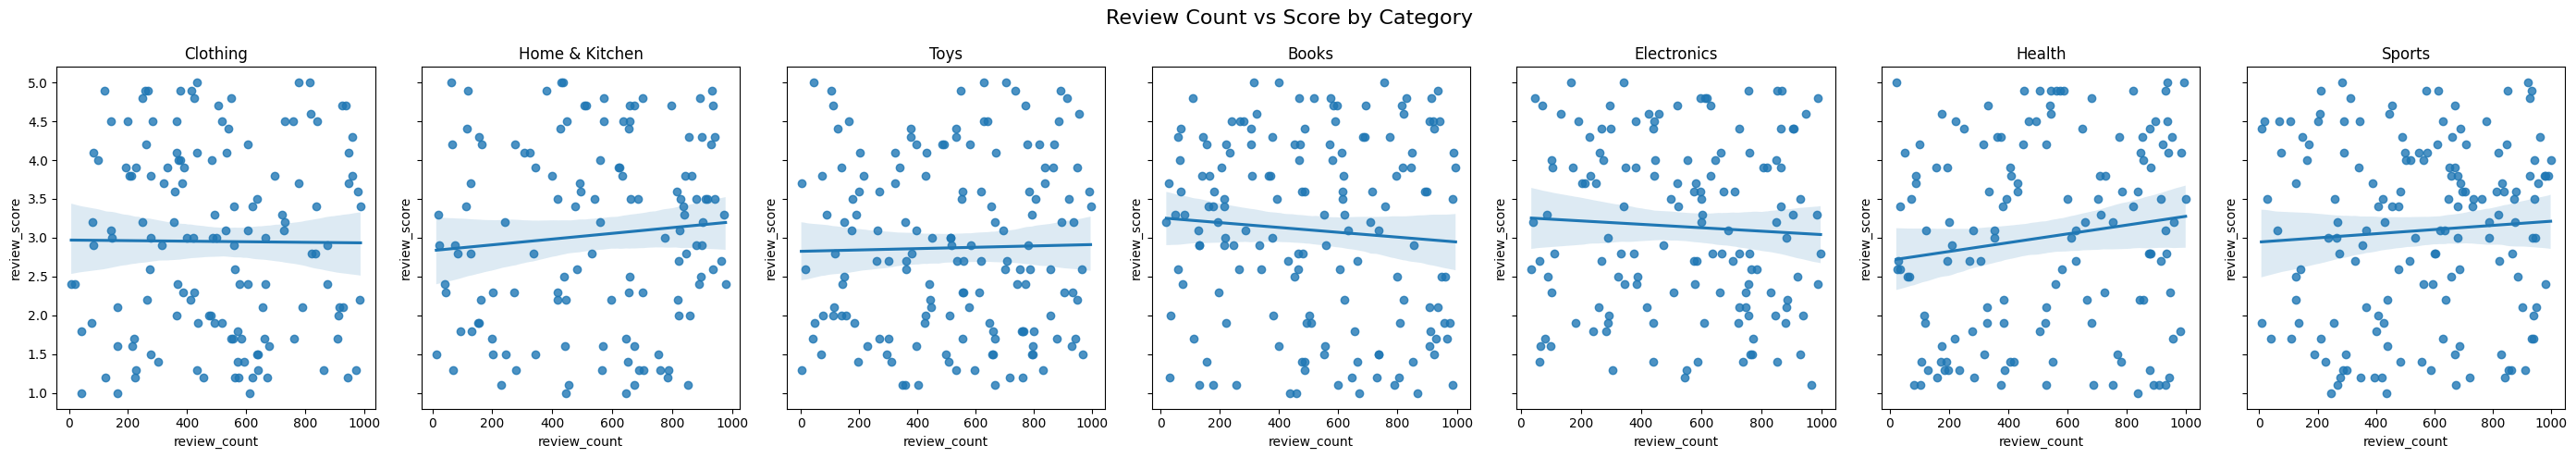

In [23]:
cate_num = len(cate)
fig, axs = plt.subplots(1, cate_num, figsize=(4*cate_num, 5), sharey=True)
fig.suptitle('Review Count vs Score by Category', fontsize=16)
for i, cat in enumerate(df_cate.keys()):
    sns.regplot(df_cate[cat], x = "review_count", y = "review_score", ax = axs[i])
    axs[i].set_title(cat)

plt.tight_layout()
plt.show()


In [24]:
review_count_score_df = pd.DataFrame([], index = ['slope', 'intercept', 'R-squared', 'p-value'], columns = cate)
for cat in df_cate.keys():
    linear_model = LinearRegression()
    linear_model.fit(df_cate[cat][["review_count"]], df_cate[cat]["review_score"])
    review_count_score_df.loc['slope', cat] = linear_model.coef_
    review_count_score_df.loc['intercept', cat] = linear_model.intercept_
    y_pred = linear_model.predict(df_cate[cat][['review_count']])
    r2 = r2_score(df_cate[cat]['review_score'], y_pred)
    review_count_score_df.loc['R-squared', cat] = r2
    f_stats, p_values = f_regression(df_cate[cat][['review_count']], df_cate[cat]['review_score'])
    review_count_score_df.loc['p-value', cat] = p_values[0]
print(review_count_score_df)

                         Clothing         Home & Kitchen  \
slope      -3.605626407096575e-05  0.0003694322146945118   
intercept                 2.97026               2.835012   
R-squared                0.000062               0.008027   
p-value                  0.926687               0.320406   

                            Toys                    Books  \
slope      8.670585771284445e-05  -0.00031156075484232385   
intercept               2.825398                 3.257112   
R-squared               0.000471                 0.005684   
p-value                 0.791299                 0.352719   

                      Electronics                 Health  \
slope      -0.0002202277585980825  0.0005673633267741918   
intercept                3.261351               2.709525   
R-squared                0.003122               0.018952   
p-value                  0.515095               0.106075   

                           Sports  
slope      0.00026769005552217963  
intercept           

After spliting the data by different categories, the relationship between review count and score is still not significant

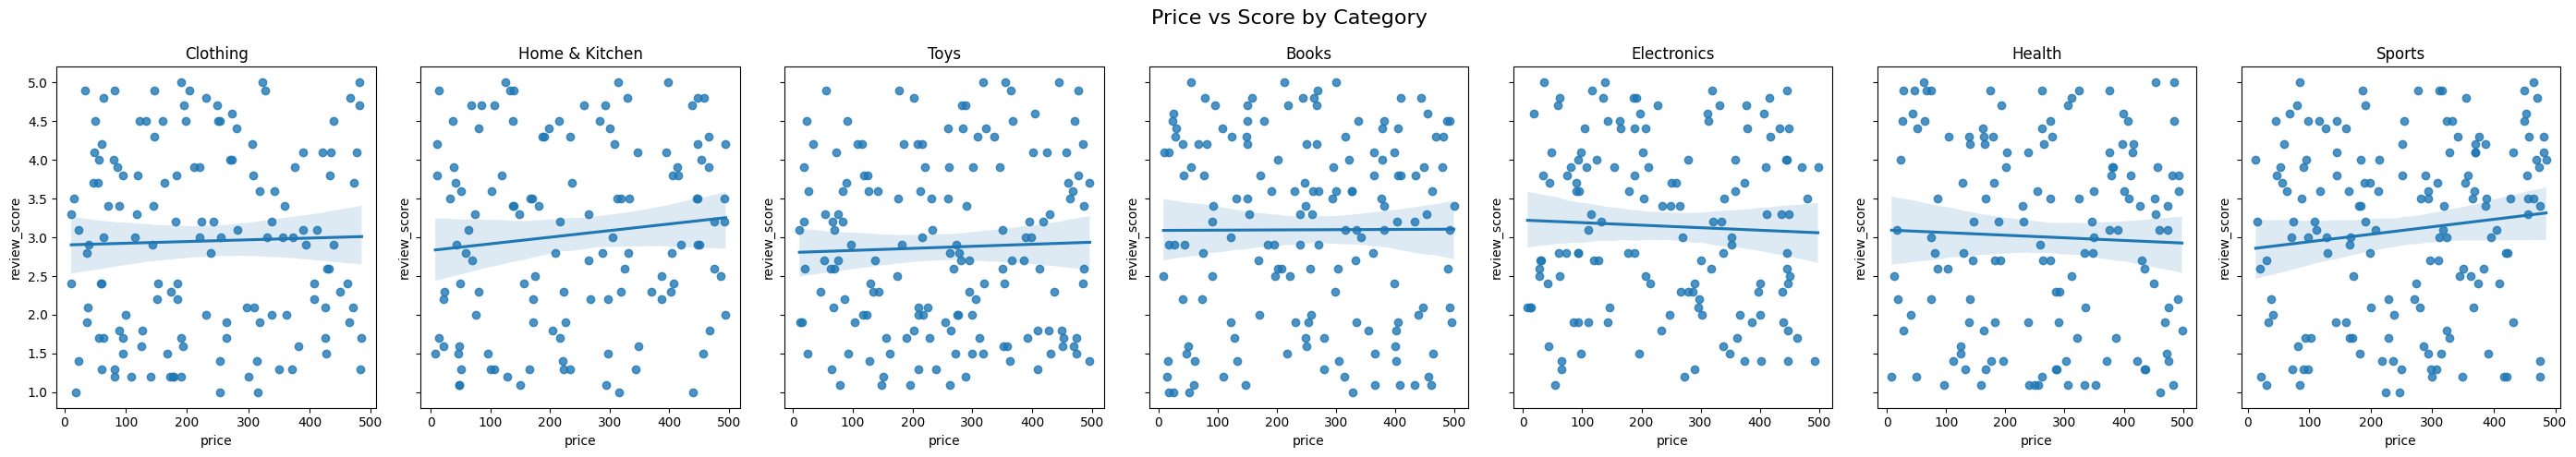

In [25]:
fig, axs = plt.subplots(1, cate_num, figsize=(4*cate_num, 5), sharey=True)
fig.suptitle('Price vs Score by Category', fontsize=16)
for i, cat in enumerate(df_cate.keys()):
    sns.regplot(df_cate[cat], x = "price", y = "review_score", ax = axs[i])
    axs[i].set_title(cat)

plt.tight_layout()
plt.show()


In [26]:
price_score_df = pd.DataFrame([], index = ['slope', 'intercept', 'R-squared', 'p-value'], columns = cate)
for cat in df_cate.keys():
    linear_model = LinearRegression()
    linear_model.fit(df_cate[cat][["price"]], df_cate[cat]["review_score"])
    price_score_df.loc['slope', cat] = linear_model.coef_
    price_score_df.loc['intercept', cat] = linear_model.intercept_
    y_pred = linear_model.predict(df_cate[cat][['price']])
    r2 = r2_score(df_cate[cat]['review_score'], y_pred)
    price_score_df.loc['R-squared', cat] = r2
    f_stats, p_values = f_regression(df_cate[cat][['price']], df_cate[cat]['review_score'])
    price_score_df.loc['p-value', cat] = p_values[0]
print(price_score_df)

                       Clothing         Home & Kitchen                   Toys  \
slope      0.000222980403376541  0.0008530977640056178  0.0002651277869576846   
intercept              2.900848               2.830653               2.804207   
R-squared              0.000687               0.011953               0.001164   
p-value                0.758527                0.22486               0.677556   

                            Books              Electronics  \
slope      3.1127050958053005e-05  -0.00032634544404177884   
intercept                3.088928                 3.221695   
R-squared                0.000015                 0.001864   
p-value                  0.962422                 0.615101   

                           Health                 Sports  
slope      -0.0003369601794369258  0.0009638927370566501  
intercept                3.094378               2.846466  
R-squared                0.001552               0.013407  
p-value                  0.645211              

All the relationships between price and review score is not that significant.

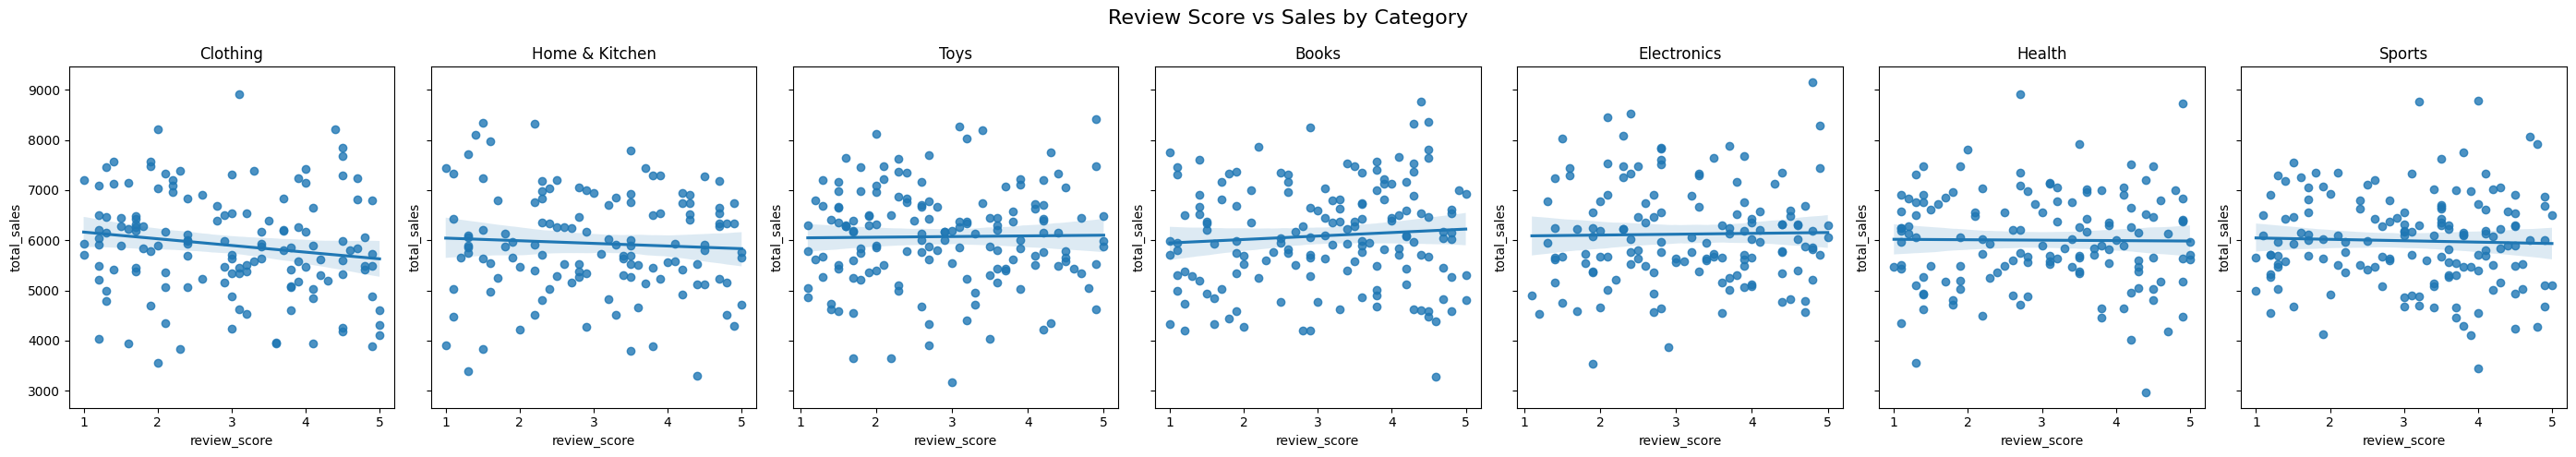

In [27]:
fig, axs = plt.subplots(1, cate_num, figsize=(4*cate_num, 5), sharey=True)
fig.suptitle('Review Score vs Sales by Category', fontsize=16)
for i, cat in enumerate(df_cate.keys()):
    sns.regplot(df_cate[cat], x = "review_score", y = "total_sales", ax = axs[i])
    axs[i].set_title(cat)

plt.tight_layout()
plt.show()

In [28]:
score_sales_df = pd.DataFrame([], index = ['slope', 'intercept', 'R-squared', 'p-value'], columns = cate)
for cat in df_cate.keys():
    linear_model = LinearRegression()
    linear_model.fit(df_cate[cat][["review_score"]], df_cate[cat]["total_sales"])
    score_sales_df.loc['slope', cat] = linear_model.coef_
    score_sales_df.loc['intercept', cat] = linear_model.intercept_
    y_pred = linear_model.predict(df_cate[cat][['review_score']])
    r2 = r2_score(df_cate[cat]['total_sales'], y_pred)
    score_sales_df.loc['R-squared', cat] = r2
    f_stats, p_values = f_regression(df_cate[cat][['review_score']], df_cate[cat]['total_sales'])
    score_sales_df.loc['p-value', cat] = p_values[0]
print(score_sales_df)

                      Clothing      Home & Kitchen                Toys  \
slope      -133.41560205461778  -52.68472544597237  13.378054136044598   
intercept          6297.690488         6097.036679         6035.110023   
R-squared             0.023804            0.003717            0.000233   
p-value               0.068746            0.499404            0.852435   

                       Books        Electronics              Health  \
slope      69.18326422153093  16.93325334848092  -8.575036773504785   
intercept        5878.152606        6070.828657         6028.746711   
R-squared           0.006465           0.000345            0.000125   
p-value             0.321543           0.828848            0.896133   

                        Sports  
slope      -27.798208608956454  
intercept          6075.291194  
R-squared             0.001216  
p-value                0.66866  


Clothing is the only category has a slightly negative relationship between review score and sales, with a p-value of 0.069. It is an interesting finding that we should investigate.

In [29]:
inspect_df = df_cate['Clothing'].loc[df_cate['Clothing']['review_score'] > 4.5]
print(inspect_df[['product_id', 'price', 'review_count', 'total_sales', 'total_revenue']])

     product_id   price  review_count  total_sales  total_revenue
24         25.0  230.75           250         5493     1267509.75
90         91.0   64.20           423         6054      388666.80
248       249.0  481.99           506         6815     3284761.85
277       278.0  326.73           377         3882     1268365.86
348       349.0  190.43           815         4304      819610.72
424       425.0   33.49           120         5489      183826.61
455       456.0  248.85           937         7231     1799434.35
464       465.0  481.28           432         4602     2214850.56
466       467.0  146.43           268         4885      715310.55
512       513.0  466.70           550         5416     2527647.20
591       592.0  322.23           777         4102     1321787.46
698       699.0   81.41           258         5738      467130.58
781       782.0  273.65           817         5812     1590453.80
864       865.0  203.38           416         6801     1383187.38
955       

Given that the price range of a product is 0 to 500, and total sales range is 3500 to 9000. Since the review count for highly rated products are at least 120, there are no contamination of review score. The main reason of high review score products having low sales could be due to high price or low popularity. We should put our focus of advertisment on high review score product in this year.

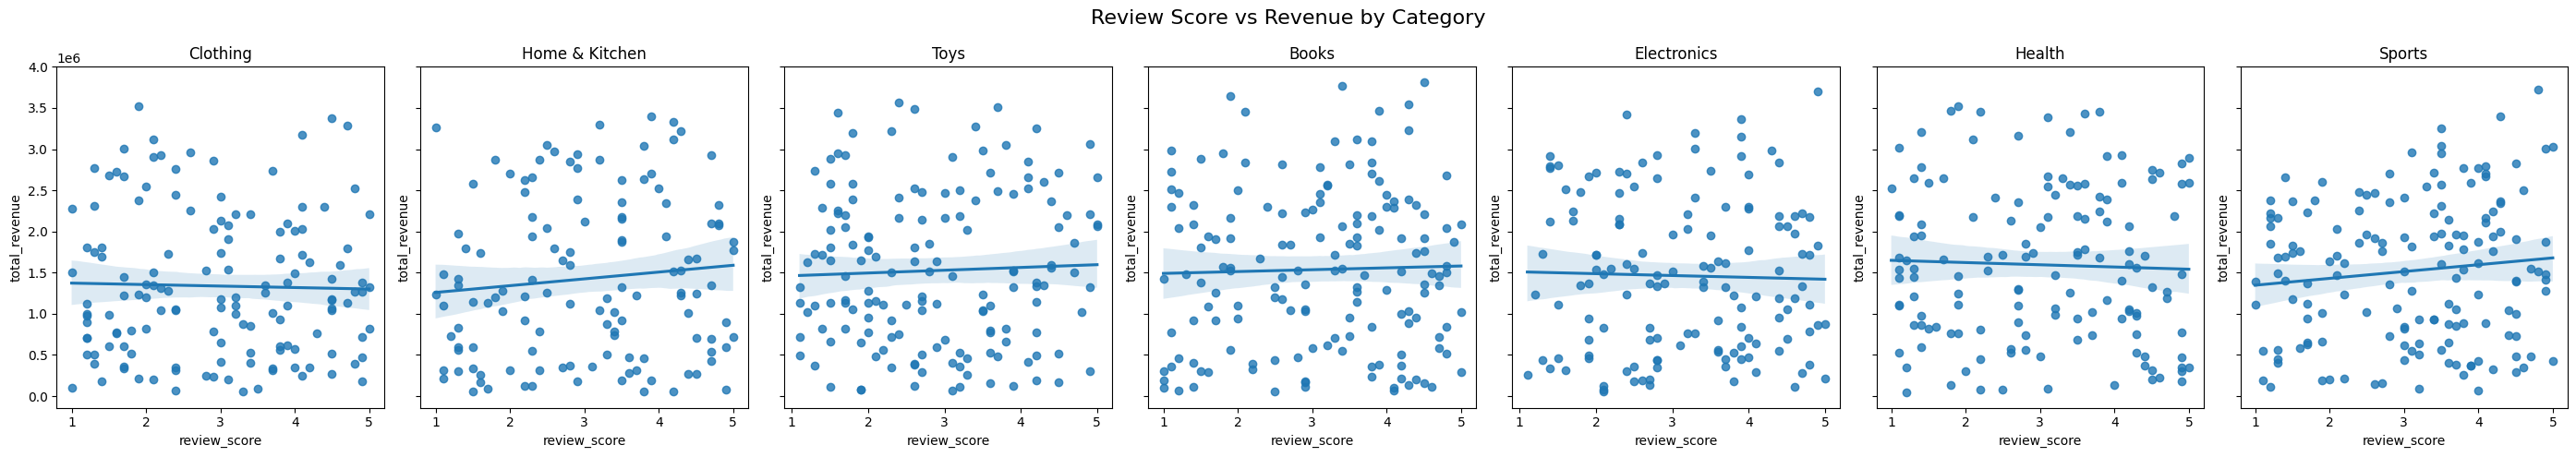

In [30]:
fig, axs = plt.subplots(1, cate_num, figsize=(4*cate_num, 5), sharey=True)
fig.suptitle('Review Score vs Revenue by Category', fontsize=16)
for i, cat in enumerate(df_cate.keys()):
    sns.regplot(df_cate[cat], x = "review_score", y = "total_revenue", ax = axs[i])
    axs[i].set_title(cat)

plt.tight_layout()
plt.show()

In [31]:
score_revenue_df = pd.DataFrame([], index = ['slope', 'intercept', 'R-squared', 'p-value'], columns = cate)
for cat in df_cate.keys():
    linear_model = LinearRegression()
    linear_model.fit(df_cate[cat][["review_score"]], df_cate[cat]["total_revenue"])
    score_revenue_df.loc['slope', cat] = linear_model.coef_
    score_revenue_df.loc['intercept', cat] = linear_model.intercept_
    y_pred = linear_model.predict(df_cate[cat][['review_score']])
    r2 = r2_score(df_cate[cat]['total_revenue'], y_pred)
    score_revenue_df.loc['R-squared', cat] = r2
    f_stats, p_values = f_regression(df_cate[cat][['review_score']], df_cate[cat]['total_revenue'])
    score_revenue_df.loc['p-value', cat] = p_values[0]
print(score_revenue_df)

                      Clothing     Home & Kitchen               Toys  \
slope      -17934.569509187633  82555.27239309615  33637.03366915618   
intercept       1390504.845915     1176352.279312     1428182.312148   
R-squared             0.000619           0.010324            0.00164   
p-value               0.770521           0.259537           0.621514   

                        Books          Electronics               Health  \
slope      22523.640785321968  -22523.253090476654  -26961.308895356182   
intercept      1467800.527984       1532212.110584       1676248.855076   
R-squared            0.000791             0.000707             0.001279   
p-value              0.729218             0.756827             0.675993   

                      Sports  
slope      82910.68791555462  
intercept     1264261.937882  
R-squared           0.012378  
p-value             0.170966  


All the relationships between review score and revenue by category are insignificant.

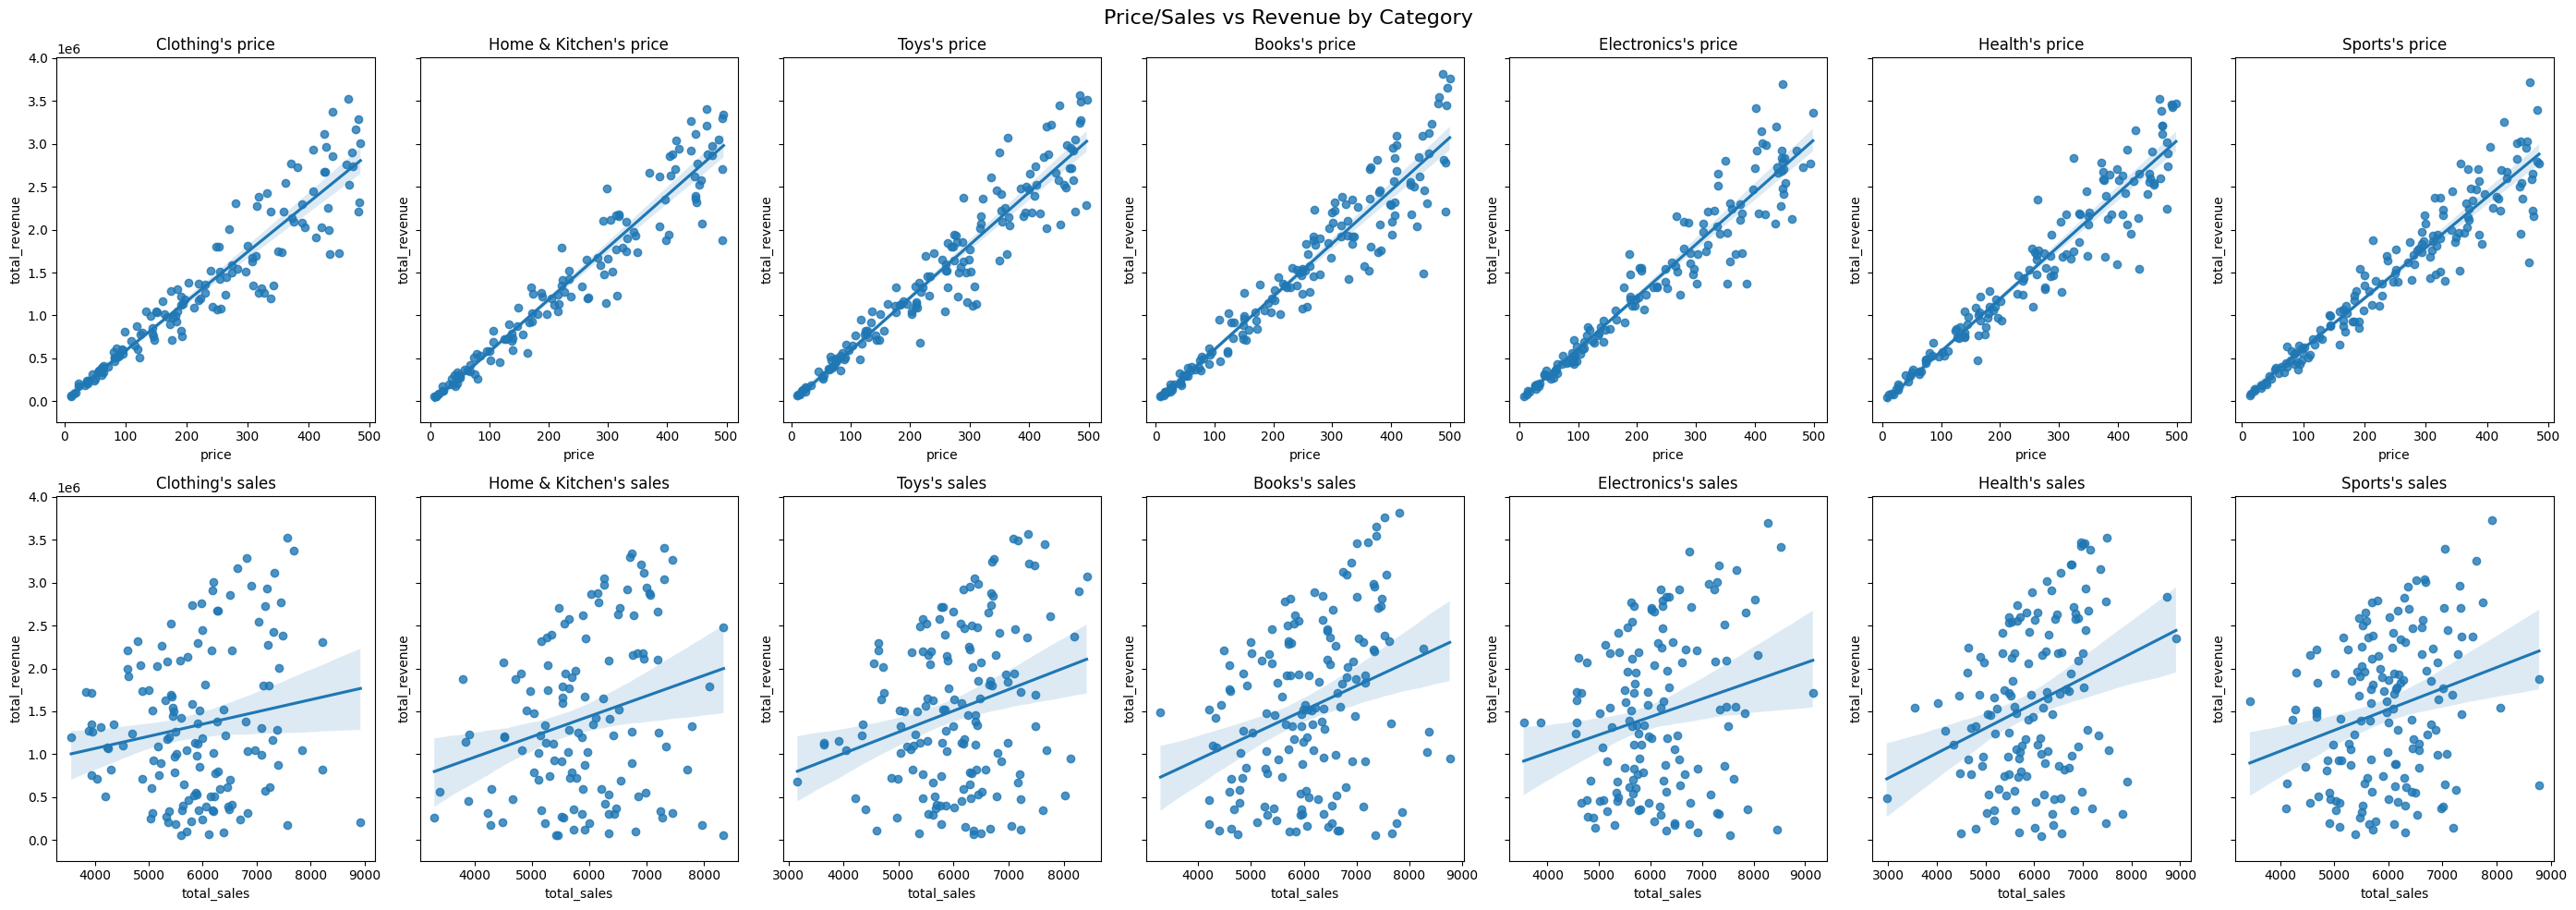

In [32]:
fig, axs = plt.subplots(2, cate_num, figsize=(4*cate_num, 5*2), sharey=True)
fig.suptitle('Price/Sales vs Revenue by Category', fontsize=16)
for i, cat in enumerate(df_cate.keys()):
    sns.regplot(df_cate[cat], x = "price", y = "total_revenue", ax = axs[0][i])
    sns.regplot(df_cate[cat], x = "total_sales", y = "total_revenue", ax = axs[1][i])
    axs[0][i].set_title(f"{cat}'s price")
    axs[1][i].set_title(f"{cat}'s sales")

plt.tight_layout()
plt.show()


In [33]:
price_sales_revenue_df = pd.DataFrame([], index = ['slope_price', 'slope_sales', 'intercept', 'R-squared', 'p-value_price', 'p-value_sales'], columns = cate)
for cat in df_cate.keys():
    linear_model = LinearRegression()
    X = df_cate[cat][['price', 'total_sales']]
    X_mean = X.mean()
    X_std = X.std()
    X_norm = (X - X_mean)/X_std
    linear_model.fit(X_norm, df_cate[cat]["total_revenue"])
    price_sales_revenue_df.loc['slope_price', cat] = linear_model.coef_[0]
    price_sales_revenue_df.loc['slope_sales', cat] = linear_model.coef_[1]
    price_sales_revenue_df.loc['intercept', cat] = linear_model.intercept_
    y_pred = linear_model.predict(X_norm)
    r2 = r2_score(df_cate[cat]['total_revenue'], y_pred)
    price_sales_revenue_df.loc['R-squared', cat] = r2
    f_stats, p_values = f_regression(X_norm, df_cate[cat]['total_revenue'])
    price_sales_revenue_df.loc['p-value_price', cat] = p_values[0]
    price_sales_revenue_df.loc['p-value_sales', cat] = p_values[1]
print(price_sales_revenue_df)

                     Clothing Home & Kitchen            Toys           Books  \
slope_price      853163.45411  922429.929872   885357.051574   898746.097032   
slope_sales     267967.671429  224889.806143   256536.457411   258985.653368   
intercept      1337559.434643  1426924.04208  1524749.557815  1537550.685714   
R-squared            0.974394        0.97519        0.981374        0.972645   
p-value_price             0.0            0.0             0.0             0.0   
p-value_sales        0.043904       0.004335         0.00115        0.000104   

                 Electronics          Health          Sports  
slope_price    891836.211674   887260.319402   819134.973121  
slope_sales    248310.728617   255202.639807    237554.07745  
intercept      1461410.75413  1595229.152014  1520580.600523  
R-squared           0.976546        0.980181        0.977474  
p-value_price            0.0             0.0             0.0  
p-value_sales        0.00788        0.000397          0.0011 

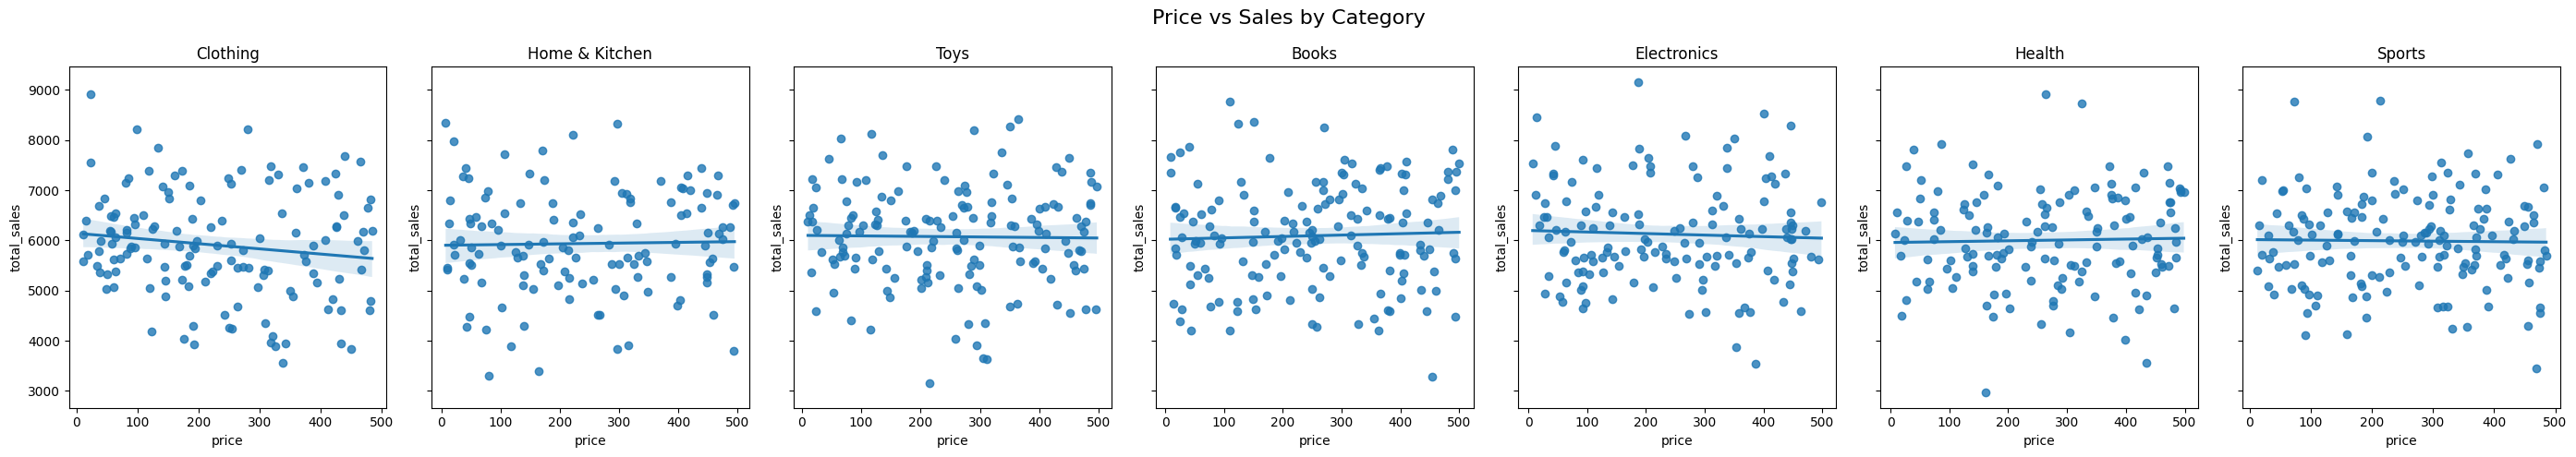

In [41]:
fig, axs = plt.subplots(1, cate_num, figsize=(4*cate_num, 5), sharey=True)
fig.suptitle('Price vs Sales by Category', fontsize=16)
for i, cat in enumerate(df_cate.keys()):
    sns.regplot(df_cate[cat], x = "price", y = "total_sales", ax = axs[i])
    axs[i].set_title(cat)

plt.tight_layout()
plt.show()

In [48]:
price_sales_df = pd.DataFrame([], index = ['slope', 'intercept', 'R-squared', 'p-value'], columns = cate)
for cat in df_cate.keys():
    linear_model = LinearRegression()
    linear_model.fit(df_cate[cat][["price"]], df_cate[cat]["total_sales"])
    price_sales_df.loc['slope', cat] = linear_model.coef_
    price_sales_df.loc['intercept', cat] = linear_model.intercept_
    y_pred = linear_model.predict(df_cate[cat][['price']])
    r2 = r2_score(df_cate[cat]['total_sales'], y_pred)
    price_sales_df.loc['R-squared', cat] = r2
    f_stats, p_values = f_regression(df_cate[cat][['price']], df_cate[cat]['total_sales'])
    price_sales_df.loc['p-value', cat] = p_values[0]
print(price_sales_df)

                      Clothing       Home & Kitchen                  Toys  \
slope      -1.0326542029885393  0.14672405385669685  -0.10508319319721153   
intercept          6141.382188          5901.948021           6099.934784   
R-squared             0.019707             0.000474              0.000238   
p-value               0.098064             0.809656              0.850889   

                        Books           Electronics               Health  \
slope      0.2796620788707919  -0.30654930230699146  0.17030002533080466   
intercept         6022.093307           6197.529953          5957.824627   
R-squared            0.001598              0.001978             0.000673   
p-value              0.622603              0.604482             0.761778   

                         Sports  
slope      -0.10555704674520043  
intercept            6016.18726  
R-squared              0.000253  
p-value                0.845254  


All the categories shown that price is a stronger component of high revenue than sales.

In [34]:
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
columns = ['price', 'review_score', 'review_count', 'total_revenue']
exploded_category = df.explode('category') 
encoder = OneHotEncoder(sparse_output=False) # initialization
encoded_category = encoder.fit_transform(exploded_category[['category']]) # a number of binary arrays
encoded_df = pd.DataFrame(encoded_category, columns=encoder.get_feature_names_out(['category'])) # add columns name for the arrays
combined_df = exploded_category[columns].reset_index(drop=True) 
final_df = pd.concat([combined_df, encoded_df], axis=1) 
final_grouped_df = final_df.groupby(columns, as_index=False).sum() 
final_grouped_df.head(5)


,price,review_score,review_count,total_revenue,category_Books,category_Clothing,category_Electronics,category_Health,category_Home & Kitchen,category_Sports,category_Toys
0,7.29,1.5,245,60776.73,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,7.51,2.1,259,56580.34,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,7.73,1.2,161,47485.39,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,8.44,2.5,960,62034.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9.55,4.1,848,73200.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
import numpy as np
from sklearn.model_selection import train_test_split
#Cate 
encoders = {}
cate_col = encoder.get_feature_names_out(['category']).tolist()
for cate in cate_col:
    final_grouped_df[cate] = final_grouped_df[cate].astype(int)
    
numer_col = ['price', 'review_score', 'review_count']
train, test = train_test_split(final_grouped_df,
                               test_size=0.33,
                               random_state=42)
numer_train, cate_train = train[numer_col].values.astype(np.float32), train[cate_col].values
numer_test, cate_test = test[numer_col].values.astype(np.float32), test[cate_col].values

y_train = train['total_revenue'].values.astype(np.float32)
y_test = test['total_revenue'].values.astype(np.float32)

#numer
scaler = preprocessing.StandardScaler()
numer_train = scaler.fit_transform(numer_train)
numer_test = scaler.transform(numer_test)

X_train = np.concatenate([numer_train, cate_train], axis=1)
X_test = np.concatenate([numer_test, cate_test], axis=1)

#y
y_scaler = preprocessing.StandardScaler()
y_train = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test = y_scaler.transform(y_test.reshape(-1, 1))

In [36]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class forecast_revenue(keras.Model):
    def __init__(self, dense_size, **kwargs): 
        super(forecast_revenue, self).__init__(**kwargs)
        self.dense_size = dense_size

        self.dropout = layers.Dropout(0.2)
        self.dense = layers.Dense(dense_size, activation='relu')
        self.dense_1 = layers.Dense(dense_size, activation='relu')
        self.dense_out = layers.Dense(1)

    def call(self, inputs, training=None):  # Add training arg for compatibility
        if isinstance(inputs, (list, tuple, dict)):
            inputs = tf.keras.backend.flatten(tf.keras.backend.concatenate(list(inputs.values()) if isinstance(inputs, dict) else inputs))
        dense_vec = self.dense(inputs)
        dense_1_vec = self.dense_1(dense_vec)
        dense_2_vec = self.dropout(dense_1_vec, training=training)
        out = self.dense_out(dense_2_vec)
        return out



In [38]:
model = forecast_revenue(dense_size=128)


metrics = [
    keras.metrics.MeanAbsoluteError(name='mae'),
    keras.metrics.RootMeanSquaredError(name='rmse')
]


model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=metrics
)
# model training
callbacks = [keras.callbacks.EarlyStopping(
    monitor='val_rmse', min_delta=0, patience=5, verbose=1,
    mode='min', baseline=None, restore_best_weights=True)]


history = model.fit(
    x=X_train,
    y=y_train,
    batch_size=64,
    epochs=50,
    verbose=1,
    validation_split=.2,
    callbacks=callbacks
)

model.summary()
model.evaluate(X_test, y_test)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.7741 - mae: 0.7406 - rmse: 0.8798 - val_loss: 0.3641 - val_mae: 0.5032 - val_rmse: 0.6034
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2625 - mae: 0.4122 - rmse: 0.5123 - val_loss: 0.1202 - val_mae: 0.2628 - val_rmse: 0.3467
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1474 - mae: 0.2881 - rmse: 0.3840 - val_loss: 0.1220 - val_mae: 0.2518 - val_rmse: 0.3492
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1328 - mae: 0.2732 - rmse: 0.3644 - val_loss: 0.0989 - val_mae: 0.2184 - val_rmse: 0.3145
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1149 - mae: 0.2529 - rmse: 0.3390 - val_loss: 0.1015 - val_mae: 0.2314 - val_rmse: 0.3187
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1172 - mae: 0.2582 - rmse: 0.3424 - val_loss: 0.0998 - val_mae: 0.2249 - val_rmse: 0.3159
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1160 - mae: 0.2507 - rmse: 0.3405 - val_loss: 0.0956 

Model: "forecast_revenue"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,149 (211.52 KB)

 Trainable params: 18,049 (70.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36,100 (141.02 KB)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1063 - mae: 0.2287 - rmse: 0.3260 


[0.10625005513429642, 0.22870568931102753, 0.3259602189064026]

In [39]:
preds_scaled = model.predict(X_test).reshape(-1, 1)
y_test_scaled_2d = y_test.reshape(-1, 1)  # y_test is scaled

preds_original = y_scaler.inverse_transform(preds_scaled).flatten()
y_test_original = y_scaler.inverse_transform(y_test_scaled_2d).flatten()

rmse_original = np.sqrt(np.mean((preds_original - y_test_original)**2))
print(f"Original RMSE: ${rmse_original:,.0f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Original RMSE: $298,221


For example, we have a new product in "Sports", sold at $333.23 and receiving 4.5 score with 73 counts in the first 3 months. Then, we can do the following transformation to predict the yearly revenue.

In [40]:
X_pred = np.array([333.23, 4.5, 73*12/3, 0, 0, 0, 0, 0, 1, 0])
X_pred[0:3] = scaler.transform(X_pred[0:3].reshape(-1, 1).T).flatten()
y_pred = y_scaler.inverse_transform(model.predict(X_pred.reshape(1, -1)).reshape(-1, 1)).flatten()
print("{:,.0f}".format(y_pred[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2,162,428
